In [1]:
import os
import cv2
import torch
import kagglehub
import numpy as np
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.svm import LinearSVC
from sklearn.linear_model import Ridge
from torchvision import models, transforms
import torchvision.ops as ops

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

d:\AI_ML\ai_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


In [2]:
path = kagglehub.dataset_download("zaraks/pascal-voc-2007")

TRAIN_PATH = os.path.join(
    path, "VOCtrainval_06-Nov-2007", "VOCdevkit", "VOC2007"
)

TEST_PATH = os.path.join(
    path, "VOCtest_06-Nov-2007", "VOCdevkit", "VOC2007"
)

print("Train path:", TRAIN_PATH)
print("Test path:", TEST_PATH)

Train path: C:\Users\DC\.cache\kagglehub\datasets\zaraks\pascal-voc-2007\versions\1\VOCtrainval_06-Nov-2007\VOCdevkit\VOC2007
Test path: C:\Users\DC\.cache\kagglehub\datasets\zaraks\pascal-voc-2007\versions\1\VOCtest_06-Nov-2007\VOCdevkit\VOC2007


In [3]:
def load_ids(dataset_path, split):
    file_path = os.path.join(dataset_path, "ImageSets", "Main", f"{split}.txt")
    with open(file_path) as f:
        return f.read().splitlines()

train_ids = load_ids(TRAIN_PATH, "trainval")
test_ids = load_ids(TEST_PATH, "test")

print("Train images:", len(train_ids))
print("Test images:", len(test_ids))

Train images: 5011
Test images: 4952


In [4]:
VOC_CLASSES = [
    'aeroplane','bicycle','bird','boat','bottle','bus','car','cat','chair',
    'cow','diningtable','dog','horse','motorbike','person','pottedplant',
    'sheep','sofa','train','tvmonitor'
]

In [5]:
def parse_xml(xml_file):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    boxes, labels = [], []

    for obj in root.findall("object"):
        name = obj.find("name")
        bbox = obj.find("bndbox")
        if name is None or bbox is None:
            continue

        xmin = int(bbox.find("xmin").text)
        ymin = int(bbox.find("ymin").text)
        xmax = int(bbox.find("xmax").text)
        ymax = int(bbox.find("ymax").text)

        boxes.append([xmin,ymin,xmax,ymax])
        labels.append(VOC_CLASSES.index(name.text))

    return np.array(boxes), np.array(labels)

In [6]:
def load_image(image_id, dataset_path):
    img_path = os.path.join(dataset_path, "JPEGImages", image_id + ".jpg")
    ann_path = os.path.join(dataset_path, "Annotations", image_id + ".xml")

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    boxes, labels = parse_xml(ann_path)
    return image, boxes, labels

In [7]:
def selective_search_regions(image):
    ss = cv2.ximgproc.segmentation.createSelectiveSearchSegmentation()
    ss.setBaseImage(image)
    ss.switchToSelectiveSearchFast()

    rects = ss.process()
    proposals = []

    for (x,y,w,h) in rects[:500]:
        proposals.append((x,y,x+w,y+h))

    return proposals

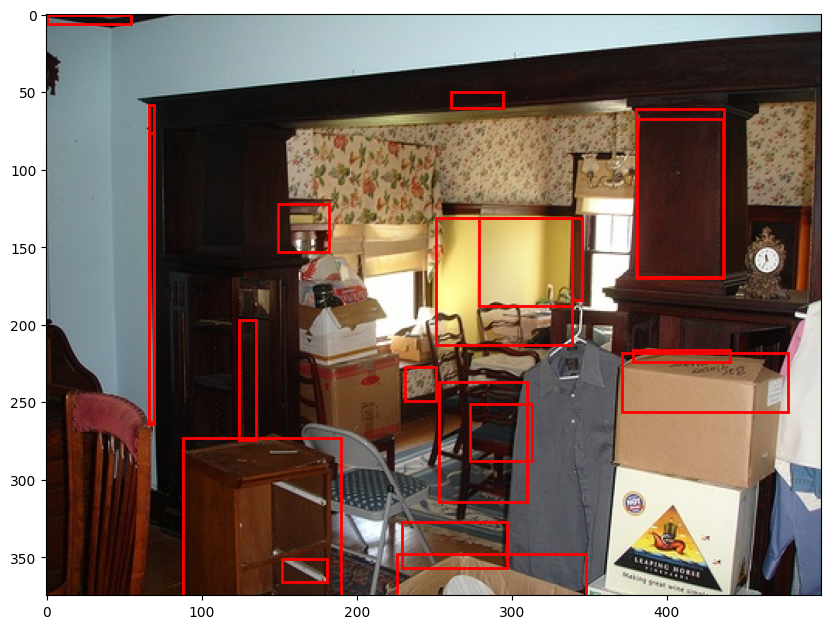

In [8]:
img, _, _ = load_image(train_ids[0], TRAIN_PATH)
props = selective_search_regions(img)

fig, ax = plt.subplots(1, figsize=(10,10))
ax.imshow(img)

for box in props[:20]:
    x1,y1,x2,y2 = box
    rect = plt.Rectangle((x1,y1), x2-x1, y2-y1,
                         fill=False, edgecolor='red', linewidth=2)
    ax.add_patch(rect)

plt.show()

In [9]:
def compute_iou(boxA, boxB):
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    inter = max(0, xB-xA) * max(0, yB-yA)

    areaA = (boxA[2]-boxA[0])*(boxA[3]-boxA[1])
    areaB = (boxB[2]-boxB[0])*(boxB[3]-boxB[1])

    return inter / (areaA + areaB - inter + 1e-6)

In [10]:
resnet = models.resnet50(weights="DEFAULT")
feature_extractor = torch.nn.Sequential(*list(resnet.children())[:-1])
feature_extractor.to(DEVICE)
feature_extractor.eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [11]:
def extract_features_batch(image, proposals, batch_size=64):

    rois = []
    valid_props = []

    for box in proposals:
        x1,y1,x2,y2 = box
        roi = image[y1:y2, x1:x2]

        if roi.size == 0:
            continue

        roi = transform(roi)
        rois.append(roi)
        valid_props.append(box)

    if len(rois) == 0:
        return np.array([]), []

    rois = torch.stack(rois).to(DEVICE)

    features = []
    with torch.no_grad():
        for i in range(0, len(rois), batch_size):
            batch = rois[i:i+batch_size]
            feat = feature_extractor(batch)
            features.append(feat.cpu())

    features = torch.cat(features, dim=0)
    return features.numpy().reshape(len(valid_props), -1), valid_props

In [16]:
X, y, bbox_targets = [], [], []

for image_id in tqdm(train_ids[:300]):  # keep small for speed
    image, gt_boxes, gt_labels = load_image(image_id, TRAIN_PATH)
    proposals = selective_search_regions(image)
    features, proposals = extract_features_batch(image, proposals)

    for i, prop in enumerate(proposals):
        max_iou = 0
        label = -1
        target_box = None

        for j, gt in enumerate(gt_boxes):
            iou = compute_iou(prop, gt)
            if iou > max_iou:
                max_iou = iou
                label = gt_labels[j]
                target_box = gt

        if max_iou > 0.5:
            X.append(features[i])
            y.append(label)

            px1,py1,px2,py2 = prop
            gx1,gy1,gx2,gy2 = target_box

            pw = px2-px1
            ph = py2-py1
            gw = gx2-gx1
            gh = gy2-gy1

            tx = (gx1-px1)/pw
            ty = (gy1-py1)/ph
            tw = np.log(gw/pw)
            th = np.log(gh/ph)

            bbox_targets.append([tx,ty,tw,th])

X = np.array(X)
y = np.array(y)
bbox_targets = np.array(bbox_targets)

svm = LinearSVC(max_iter=5000)
svm.fit(X, y)

reg = Ridge()
reg.fit(X, bbox_targets)

100%|██████████| 300/300 [24:20<00:00,  4.87s/it]


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [17]:
def voc_ap_11_point(recalls, precisions):
    ap = 0
    for t in np.linspace(0,1,11):
        if np.sum(recalls >= t) == 0:
            p = 0
        else:
            p = np.max(precisions[recalls >= t])
        ap += p/11
    return ap

In [18]:
# ===============================
# STEP 15: R-CNN (NO REGRESSION)
# ===============================

pred_boxes_all = {}
gt_boxes_all = {}

for image_id in tqdm(test_ids[:200]):   # Use 20 images for speed

    image, gt_boxes, _ = load_image(image_id, TEST_PATH)

    proposals = selective_search_regions(image)
    features, proposals = extract_features_batch(image, proposals)

    if len(features) == 0:
        continue

    scores = svm.decision_function(features)

    boxes = []
    confidences = []

    for i, score in enumerate(scores):
        conf = np.max(score)
        if conf > 0:
            boxes.append(proposals[i])
            confidences.append(conf)

    if len(boxes) == 0:
        continue

    boxes_t = torch.tensor(boxes, dtype=torch.float32).to(DEVICE)
    conf_t = torch.tensor(confidences, dtype=torch.float32).to(DEVICE)

    keep = ops.nms(boxes_t, conf_t, 0.5)

    final_boxes = boxes_t[keep].cpu().numpy()
    final_scores = conf_t[keep].cpu().numpy()

    pred_boxes_all[image_id] = list(zip(final_boxes, final_scores))
    gt_boxes_all[image_id] = gt_boxes


# ---- Compute mAP (No Regression) ----

def compute_ap(gt_boxes_all, pred_boxes_all, iou_threshold=0.5):

    tp = []
    fp = []
    total_gt = 0

    for img_id in gt_boxes_all.keys():

        gt_boxes = gt_boxes_all[img_id]
        preds = pred_boxes_all.get(img_id, [])

        detected = []
        total_gt += len(gt_boxes)

        preds = sorted(preds, key=lambda x: x[1], reverse=True)

        for pred_box, score in preds:

            max_iou = 0
            max_idx = -1

            for i, gt_box in enumerate(gt_boxes):
                iou = compute_iou(pred_box, gt_box)
                if iou > max_iou:
                    max_iou = iou
                    max_idx = i

            if max_iou >= iou_threshold and max_idx not in detected:
                tp.append(1)
                fp.append(0)
                detected.append(max_idx)
            else:
                tp.append(0)
                fp.append(1)

    tp = np.cumsum(tp)
    fp = np.cumsum(fp)

    recalls = tp / (total_gt + 1e-6)
    precisions = tp / (tp + fp + 1e-6)

    return voc_ap_11_point(recalls, precisions)


ap_no_reg = compute_ap(gt_boxes_all, pred_boxes_all)
print("R-CNN mAP (No Regression):", ap_no_reg)

100%|██████████| 200/200 [16:00<00:00,  4.80s/it]


R-CNN mAP (No Regression): 0.008290947906921456


In [19]:
# ===============================
# STEP 16: R-CNN (WITH REGRESSION)
# ===============================

pred_boxes_all_reg = {}
gt_boxes_all_reg = {}

for image_id in tqdm(test_ids[:200]):

    image, gt_boxes, _ = load_image(image_id, TEST_PATH)

    proposals = selective_search_regions(image)
    features, proposals = extract_features_batch(image, proposals)

    if len(features) == 0:
        continue

    scores = svm.decision_function(features)

    boxes = []
    confidences = []

    for i, score in enumerate(scores):
        conf = np.max(score)

        if conf > 0:

            # Apply regression refinement
            tx, ty, tw, th = reg.predict([features[i]])[0]

            px1, py1, px2, py2 = proposals[i]

            pw = px2 - px1
            ph = py2 - py1

            gx = px1 + tx * pw
            gy = py1 + ty * ph
            gw = pw * np.exp(tw)
            gh = ph * np.exp(th)

            refined_box = [gx, gy, gx + gw, gy + gh]

            boxes.append(refined_box)
            confidences.append(conf)

    if len(boxes) == 0:
        continue

    boxes_t = torch.tensor(boxes, dtype=torch.float32).to(DEVICE)
    conf_t = torch.tensor(confidences, dtype=torch.float32).to(DEVICE)

    keep = ops.nms(boxes_t, conf_t, 0.5)

    final_boxes = boxes_t[keep].cpu().numpy()
    final_scores = conf_t[keep].cpu().numpy()

    pred_boxes_all_reg[image_id] = list(zip(final_boxes, final_scores))
    gt_boxes_all_reg[image_id] = gt_boxes


ap_with_reg = compute_ap(gt_boxes_all_reg, pred_boxes_all_reg)

print("R-CNN mAP (With Regression):", ap_with_reg)

100%|██████████| 200/200 [16:31<00:00,  4.96s/it]


R-CNN mAP (With Regression): 0.013201759345029209


In [20]:
faster_model = models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
faster_model.to(DEVICE)
faster_model.eval()

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\DC/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:20<00:00, 8.09MB/s] 


FasterRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(

In [21]:
# ===============================
# FASTER R-CNN EVALUATION
# ===============================

faster_model.to(DEVICE)
faster_model.eval()

pred_boxes_all_faster = {}
gt_boxes_all_faster = {}

for image_id in tqdm(test_ids[:20]):

    image, gt_boxes, _ = load_image(image_id, TEST_PATH)

    img_tensor = transforms.ToTensor()(image).to(DEVICE)

    with torch.no_grad():
        outputs = faster_model([img_tensor])[0]

    boxes = outputs['boxes'].detach().cpu().numpy()
    scores = outputs['scores'].detach().cpu().numpy()

    # Keep high confidence detections only
    selected = scores > 0.5
    boxes = boxes[selected]
    scores = scores[selected]

    pred_boxes_all_faster[image_id] = list(zip(boxes, scores))
    gt_boxes_all_faster[image_id] = gt_boxes


ap_faster = compute_ap(gt_boxes_all_faster, pred_boxes_all_faster)

print("Faster R-CNN mAP:", ap_faster)

100%|██████████| 20/20 [00:05<00:00,  3.91it/s]

Faster R-CNN mAP: 0.47168099223246057


In [22]:
print("----- FINAL COMPARISON -----")
print("R-CNN (No Regression):", ap_no_reg)
print("R-CNN (With Regression):", ap_with_reg)
print("Faster R-CNN:", ap_faster)

----- FINAL COMPARISON -----
R-CNN (No Regression): 0.008290947906921456
R-CNN (With Regression): 0.013201759345029209
Faster R-CNN: 0.47168099223246057
